<a href="https://colab.research.google.com/github/FDB1228/Optimization_methods/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Лабораторная работа №4. Метод Ньютона**
Выполнил: студент группы ФН2-61 Тихомиров С.И.

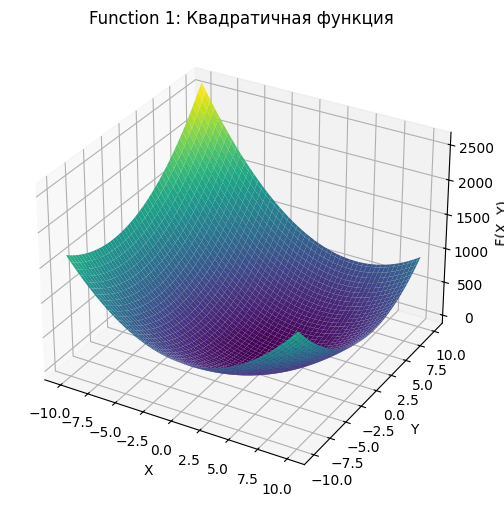

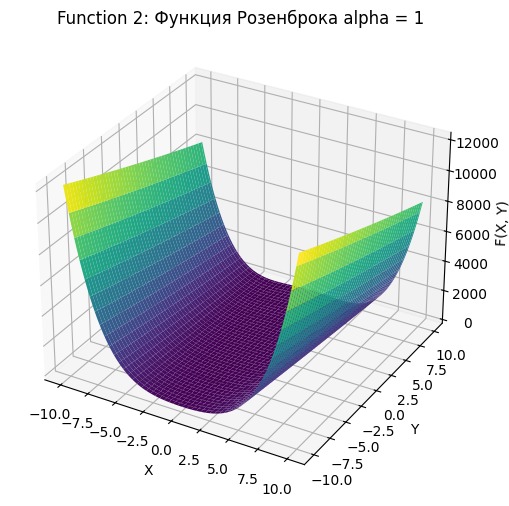

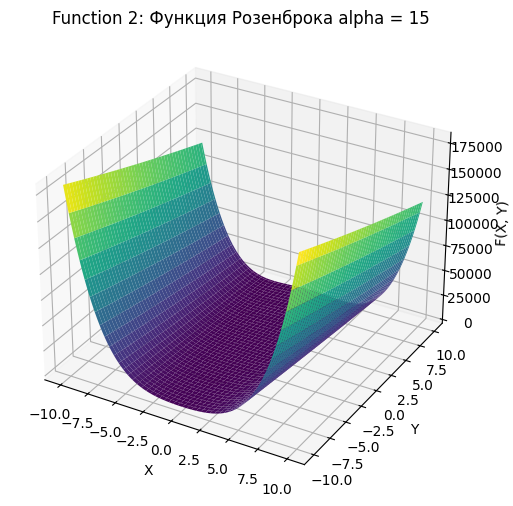

In [ ]:
# @title Графики функций
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from typing import Callable, List, Tuple
from numpy.linalg import norm

import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, List, Tuple

# Функции для оптимизации
def f1(x: np.ndarray) -> float:
    """Квадратичная функция."""
    return (10 * x[0] ** 2
            - 4 * x[0] * x[1]
            + 7 * x[1] ** 2
            - 4 * np.sqrt(5) * (5 * x[0] - x[1])
            - 16)

def f2(x: np.ndarray) -> float:
    """Функция Розенброка."""
    return (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2

def f3(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 15"""
    return 15 * (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2

# Производные функций
def f1dx(x: np.ndarray) -> float:
    return 20 * x[0] - 4 * x[1] - 20 * np.sqrt(5)

def f1dy(x: np.ndarray) -> float:
    return -4 * x[0] + 14 * x[1] + 4 * np.sqrt(5)

def f2dx(x: np.ndarray) -> float:
    return 4 * x[0] * (x[0] ** 2 - x[1]) + 2 * (x[0] - 1)

def f2dy(x: np.ndarray) -> float:
    return -2 * (x[0] ** 2 - x[1])

def f3dx(x: np.ndarray) -> float:
    return 60 * x[0] * ((x[0] ** 2) - x[1]) + 2 * (x[0] - 1)

def f3dy(x: np.ndarray) -> float:
    return -30 * ((x[0] ** 2) - x[1])

# Гессианы
def hessian_f1(_: np.ndarray) -> np.ndarray:
    """Гессиан для первой функции (постоянная матрица)."""
    return np.array([[20, -4], [-4, 14]])

def hessian_f2(x: np.ndarray) -> np.ndarray:
    """Гессиан для функции Розенброка."""
    h_11 = 4 * (3 * x[0] ** 2 - x[1]) + 2
    h_12 = -4 * x[0]
    h_22 = 2
    return np.array([[h_11, h_12], [h_12, h_22]])

def hessian_f3(x: np.ndarray) -> np.ndarray:
    """Гессиан для функции Розенброка."""
    h_11 = 60 * (3 * x[0] ** 2 - x[1]) + 2
    h_12 = -60 * x[0]
    h_22 = 30
    return np.array([[h_11, h_12], [h_12, h_22]])

# Вспомогательные функции

def golden_section_search(
    f: Callable[[float], float], a: float, b: float, tol: float) -> float:
    """Метод золотого сечения"""
    phi = (1 + np.sqrt(5)) / 2
    resphi = 2 - phi
    f_evals = 2

    x1, x2 = a + resphi * (b - a), b - resphi * (b - a)
    f1, f2 = f(x1), f(x2)

    while abs(b - a) > tol:
        if f1 < f2:
            b, x2, f2 = x2, x1, f1
            x1 = a + resphi * (b - a)
            f1 = f(x1)
        else:
            a, x1, f1 = x1, x2, f2
            x2 = b - resphi * (b - a)
            f2 = f(x2)
        f_evals+=1
    return (a + b) / 2 , f_evals


def generate_mesh_data(
    f: Callable[[np.ndarray], float],
    x_range: Tuple[float, float] = (-10, 10),
    y_range: Tuple[float, float] = (-10, 10),
    resolution: int = 100
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Генерация сетки для построения 3D-графика функции."""
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    x_grid, y_grid = np.meshgrid(x, y)
    z_grid = np.array([[f(np.array([xi, yi])) for xi in x] for yi in y])
    return x_grid, y_grid, z_grid

def plot_3d_function(f: Callable[[np.ndarray], float], title: str = "3D Function Plot") -> None:
    """Отрисовка 3D-графика функции."""
    x_grid, y_grid, z_grid = generate_mesh_data(f)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection="3d")
    ax.plot_surface(x_grid, y_grid, z_grid, cmap="viridis")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("F(X, Y)")
    ax.set_title(title)
    plt.show()

def regularized_inverse(
    matrix: np.ndarray,
    max_iter: int = 1000,
    lambda_step: float = 0.1,
    lambda_init: float = 0.01
) -> np.ndarray:
    """
    Вычисление обратной матрицы с регуляризацией.
    Добавляет к диагонали матрицы λI для обеспечения положительной определенности.
    """
    n = matrix.shape[0]
    lambda_current = lambda_init

    for _ in range(max_iter):
        try:
            regularized = matrix + lambda_current * np.eye(n)
            # Проверка на положительную определенность
            if np.all(np.linalg.eigvals(regularized) > 0):
                return np.linalg.inv(regularized)
        except np.linalg.LinAlgError:
            pass
        lambda_current += lambda_step

    raise ValueError("Не удалось обратить матрицу после регуляризации.")


if __name__ == "__main__":
    plot_3d_function(f1, "Function 1: Квадратичная функция")
    plot_3d_function(f2, "Function 2: Функция Розенброка alpha = 1")
    plot_3d_function(f3, "Function 2: Функция Розенброка alpha = 15")


матрница Гессе 
 [[310. -20.]
 [-20.   2.]] 

собственные значения матрицы Гессе 
 [311.29327094   0.70672906] 

число обусловленностиматрицы Гессе 
 440.4704569729054 

точка [ 4.90372898 23.90775103] 

матрница Гессе 
 [[194.9276906  -19.61491591]
 [-19.61491591   2.        ]] 

собственные значения матрицы Гессе 
 [1.96901736e+02 2.59543416e-02] 

число обусловленностиматрицы Гессе 
 7586.466246387588 

точка [2.68330655 2.37750953] 

матрница Гессе 
 [[ 78.89157064 -10.73322622]
 [-10.73322622   2.        ]] 

собственные значения матрицы Гессе 
 [80.36170387  0.52986677] 

число обусловленностиматрицы Гессе 
 151.66398190836188 

точка [2.51542194 6.27965157] 

матрница Гессе 
 [[ 52.80956398 -10.06168775]
 [-10.06168775   2.        ]] 

собственные значения матрицы Гессе 
 [54.72950538  0.0800586 ] 

число обусловленностиматрицы Гессе 
 683.6180578088123 

точка [1.2786901  0.13625969] 

матрница Гессе 
 [[21.07554166 -5.11476039]
 [-5.11476039  2.        ]] 

собственные значени

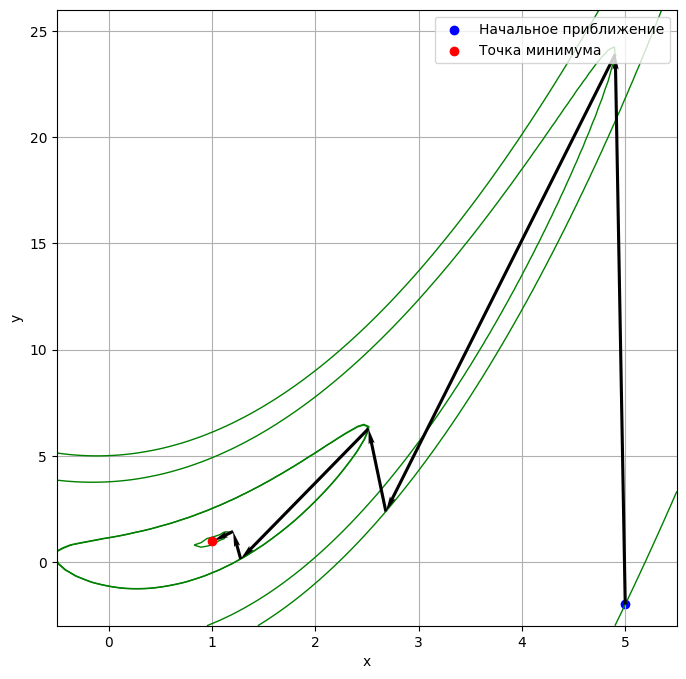

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество итераций: 7 

матрница Гессе 
 [[310. -20.]
 [-20.   2.]] 

собственные значения матрицы Гессе 
 [311.29327094   0.70672906] 

число обусловленностиматрицы Гессе 
 440.4704569729054 

точка [ 4.90372898 23.90775103] 

матрница Гессе 
 [[194.9276906  -19.61491591]
 [-19.61491591   2.        ]] 

собственные значения матрицы Гессе 
 [1.96901736e+02 2.59543416e-02] 

число обусловленностиматрицы Гессе 
 7586.466246387588 

точка [2.68330655 2.37750953] 

матрница Гессе 
 [[ 78.89157064 -10.73322622]
 [-10.73322622   2.        ]] 

собственные значения матрицы Гессе 
 [80.36170387  0.52986677] 

число обусловленностиматрицы Гессе 
 151.66398190836188 

точка [2.51542194 6.27965157] 

матрница Гессе 
 [[ 52.80956398 -10.06168775]
 [-10.06168775   2.        ]] 

собственные значения матрицы Гессе 
 [54.72950538  0.0800586 ] 

число обусловленностиматрицы Гессе 
 683.6180578088123 

точка 

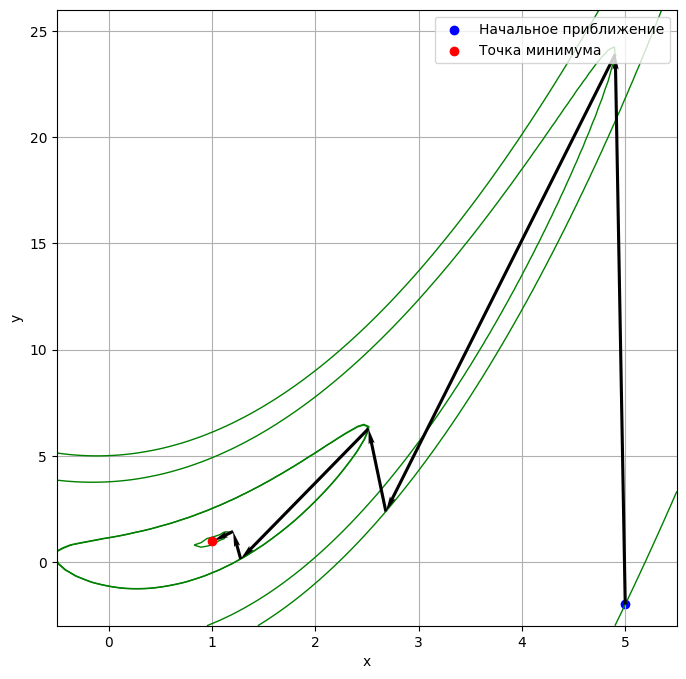

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество итераций: 9 

матрница Гессе 
 [[262.  20.]
 [ 20.   2.]] 

собственные значения матрицы Гессе 
 [263.52946438   0.47053562] 

число обусловленностиматрицы Гессе 
 560.0627306147582 

точка [-4.78584982 22.79452559] 

матрница Гессе 
 [[185.67419983  19.14339929]
 [ 19.14339929   2.        ]] 

собственные значения матрицы Гессе 
 [1.87648201e+02 2.59989885e-02] 

число обусловленностиматрицы Гессе 
 7217.519284900402 

точка [-1.33975059 -9.91711013] 

матрница Гессе 
 [[63.20762011  5.35900234]
 [ 5.35900234  2.        ]] 

собственные значения матрицы Гессе 
 [63.67328215  1.53433796] 

число обусловленностиматрицы Гессе 
 41.49886377215145 

точка [-1.23773129  1.46466195] 

матрница Гессе 
 [[14.52509713  4.95092515]
 [ 4.95092515  2.        ]] 

собственные значения матрицы Гессе 
 [16.24572928  0.27936784] 

число обусловленностиматрицы Гессе 
 58.1517507450729 

точ

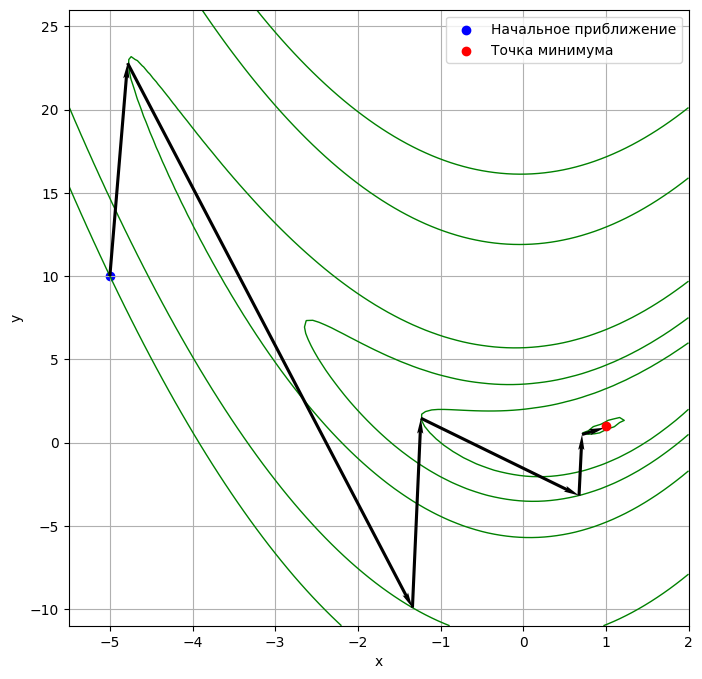

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 0.99
Значение функции f(x,y)=0.00
Количество итераций: 7 

матрница Гессе 
 [[262.  20.]
 [ 20.   2.]] 

собственные значения матрицы Гессе 
 [263.52946438   0.47053562] 

число обусловленностиматрицы Гессе 
 560.0627306147582 

точка [-4.78584982 22.79452559] 

матрница Гессе 
 [[185.67419983  19.14339929]
 [ 19.14339929   2.        ]] 

собственные значения матрицы Гессе 
 [1.87648201e+02 2.59989885e-02] 

число обусловленностиматрицы Гессе 
 7217.519284900402 

точка [-1.33975059 -9.91711013] 

матрница Гессе 
 [[63.20762011  5.35900234]
 [ 5.35900234  2.        ]] 

собственные значения матрицы Гессе 
 [63.67328215  1.53433796] 

число обусловленностиматрицы Гессе 
 41.49886377215145 

точка [-1.23773129  1.46466195] 

матрница Гессе 
 [[14.52509713  4.95092515]
 [ 4.95092515  2.        ]] 

собственные значения матрицы Гессе 
 [16.24572928  0.27936784] 

число обусловленностиматрицы Гессе 
 58.1517507450729 

точка [ 0.6

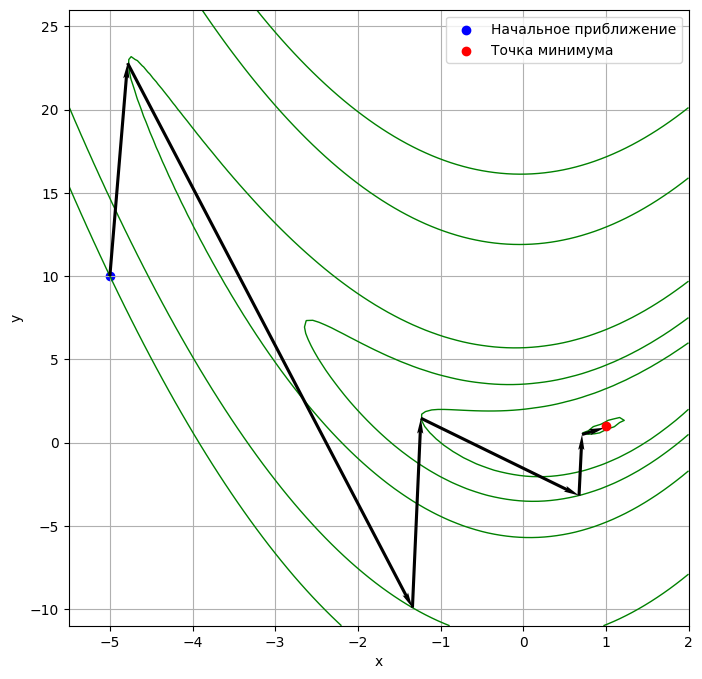

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 0.99999
Значение функции f(x,y)=0.00000
Количество итераций: 9 

матрница Гессе 
 [[4622. -300.]
 [-300.   30.]] 

собственные значения матрицы Гессе 
 [4641.5163571   10.4836429] 

число обусловленностиматрицы Гессе 
 442.73888395461495 

точка [ 4.99340786 24.92510361] 

матрница Гессе 
 [[2994.63576111 -299.60447185]
 [-299.60447185   30.        ]] 

собственные значения матрицы Гессе 
 [3.02461056e+03 2.52043303e-02] 

число обусловленностиматрицы Гессе 
 120003.60746990876 

точка [2.74216873 2.45890046] 

матрница Гессе 
 [[1207.97405626 -164.53012391]
 [-164.53012391   30.        ]] 

собственные значения матрицы Гессе 
 [1230.52270246    7.4513538 ] 

число обусловленностиматрицы Гессе 
 165.14082350704442 

точка [2.72987315 7.45039239] 

матрница Гессе 
 [[ 896.37378948 -163.7923889 ]
 [-163.7923889    30.        ]] 

собственные значения матрицы Гессе 
 [9.26305489e+02 6.83003851e-02] 

число обусловленностиматр

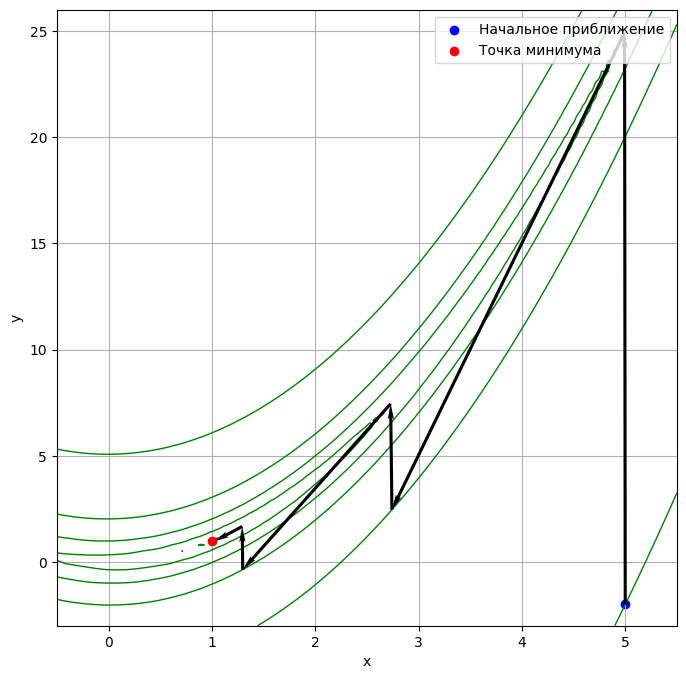

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество итераций: 8 

матрница Гессе 
 [[4622. -300.]
 [-300.   30.]] 

собственные значения матрицы Гессе 
 [4641.5163571   10.4836429] 

число обусловленностиматрицы Гессе 
 442.73888395461495 

точка [ 4.99340786 24.92510361] 

матрница Гессе 
 [[2994.63576111 -299.60447185]
 [-299.60447185   30.        ]] 

собственные значения матрицы Гессе 
 [3.02461056e+03 2.52043303e-02] 

число обусловленностиматрицы Гессе 
 120003.60746990876 

точка [2.74216873 2.45890046] 

матрница Гессе 
 [[1207.97405626 -164.53012391]
 [-164.53012391   30.        ]] 

собственные значения матрицы Гессе 
 [1230.52270246    7.4513538 ] 

число обусловленностиматрицы Гессе 
 165.14082350704442 

точка [2.72987315 7.45039239] 

матрница Гессе 
 [[ 896.37378948 -163.7923889 ]
 [-163.7923889    30.        ]] 

собственные значения матрицы Гессе 
 [9.26305489e+02 6.83003851e-02] 

число обусловленностиматрицы Гессе 

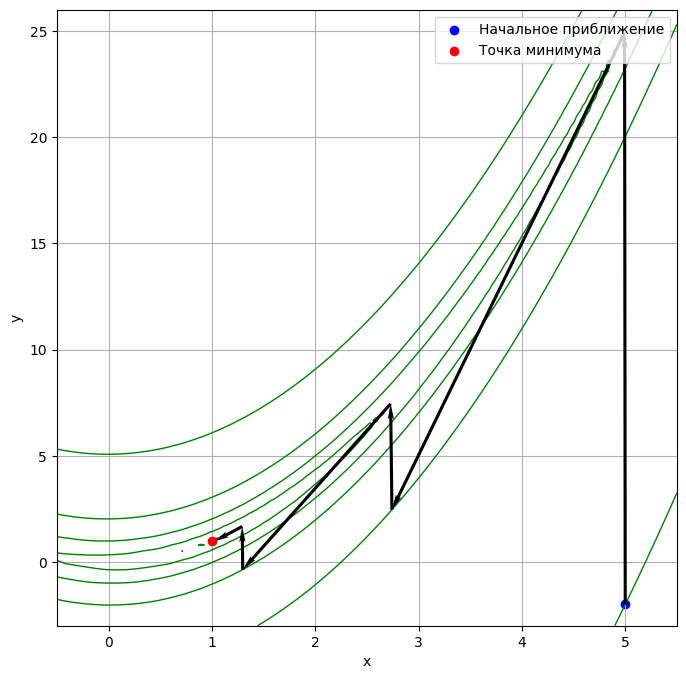

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество итераций: 10 

матрница Гессе 
 [[3902.  300.]
 [ 300.   30.]] 

собственные значения матрицы Гессе 
 [3925.10591853    6.89408147] 

число обусловленностиматрицы Гессе 
 569.344289417614 

точка [-4.98505055 24.84555696] 

матрница Гессе 
 [[2984.39779558  299.10303285]
 [ 299.10303285   30.        ]] 

собственные значения матрицы Гессе 
 [3.01437480e+03 2.29930296e-02] 

число обусловленностиматрицы Гессе 
 131099.50487108328 

точка [ -1.37293506 -11.15042893] 

матрница Гессе 
 [[1010.31685922   82.37610373]
 [  82.37610373   30.        ]] 

собственные значения матрицы Гессе 
 [1017.19073095   23.12612826] 

число обусловленностиматрицы Гессе 
 43.98448021362506 

точка [-1.36642699  1.86274263] 

матрница Гессе 
 [[226.31753008  81.98561923]
 [ 81.98561923  30.        ]] 

собственные значения матрицы Гессе 
 [256.05241193   0.26511815] 

число обусловленностиматрицы

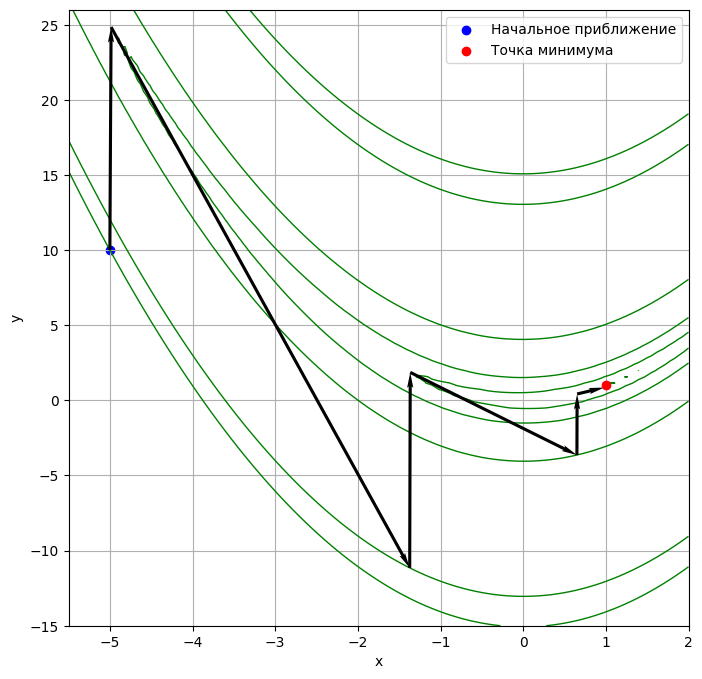

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество итераций: 9 

матрница Гессе 
 [[3902.  300.]
 [ 300.   30.]] 

собственные значения матрицы Гессе 
 [3925.10591853    6.89408147] 

число обусловленностиматрицы Гессе 
 569.344289417614 

точка [-4.98505055 24.84555696] 

матрница Гессе 
 [[2984.39779558  299.10303285]
 [ 299.10303285   30.        ]] 

собственные значения матрицы Гессе 
 [3.01437480e+03 2.29930296e-02] 

число обусловленностиматрицы Гессе 
 131099.50487108328 

точка [ -1.37293506 -11.15042893] 

матрница Гессе 
 [[1010.31685922   82.37610373]
 [  82.37610373   30.        ]] 

собственные значения матрицы Гессе 
 [1017.19073095   23.12612826] 

число обусловленностиматрицы Гессе 
 43.98448021362506 

точка [-1.36642699  1.86274263] 

матрница Гессе 
 [[226.31753008  81.98561923]
 [ 81.98561923  30.        ]] 

собственные значения матрицы Гессе 
 [256.05241193   0.26511815] 

число обусловленностиматрицы Гессе 
 

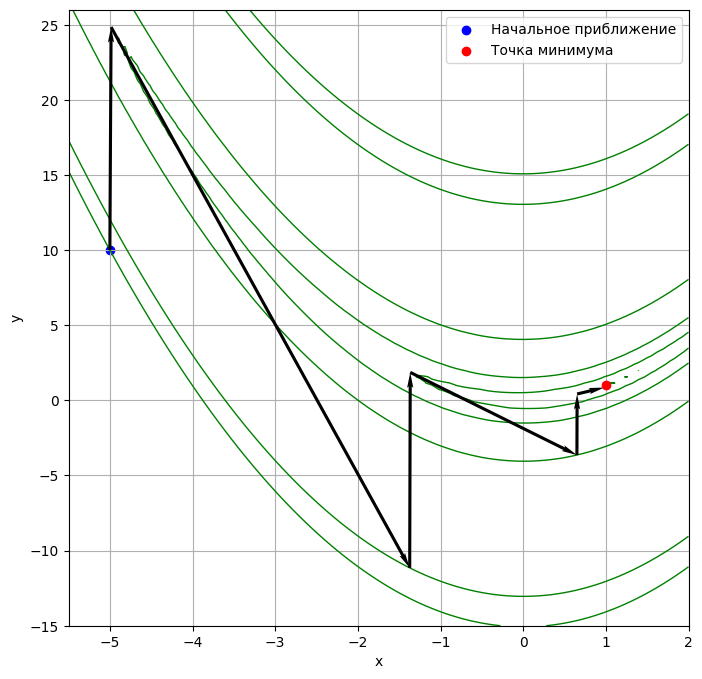

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество итераций: 10 



In [ ]:
# @title Метод Ньютона
def newton_method(
    f: Callable[[np.ndarray], float],
    grad_x: Callable[[np.ndarray], float],
    grad_y: Callable[[np.ndarray], float],
    hessian: Callable[[np.ndarray], np.ndarray],
    x0: List[float],
    bounds: Tuple[float, float],
    eps: float,
    max_iter: int = 5000
) -> np.ndarray:
    """
    Метод Ньютона для поиска минимума функции двух переменных.
    """
    i = 0
    opt = np.array(x0, dtype=float)
    grad = -np.array([grad_x(opt), grad_y(opt)])
    grad_norm = np.linalg.norm(grad)
    hes_i = 0
    grad_i = 1
    fig, ax = plt.subplots(figsize=(8, 8))

    x_vals = np.linspace(bounds[0][0], bounds[0][1], 100)
    y_vals = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.array([[f(np.array([xi, yi])) for xi in x_vals] for yi in y_vals])


    ax.scatter(*x0, color="blue", label="Начальное приближение")
    start_level = f(opt)
    cs = ax.contour(X, Y, Z, levels=[start_level], colors='green', linewidths=1)

    path = [opt.copy()]

    draw_iterations = []

    for iteration in range(max_iter):
        if grad_norm <= eps:
            break

        hess_inv = regularized_inverse(hessian(opt))
        print(f'матрница Гессе \n {hessian(opt)} \n')
        print(f'собственные значения матрицы Гессе \n {np.linalg.eigvals(hessian(opt))} \n')
        print(f'число обусловленностиматрицы Гессе \n {np.linalg.cond(hessian(opt))} \n')
        hes_i += 1
        step = hess_inv @ grad

        x_start, y_start = opt[0], opt[1]
        opt += step
        x_end, y_end = opt[0], opt[1]
        print(f'точка {opt} \n')
        grad = -np.array([grad_x(opt), grad_y(opt)])
        grad_norm = np.linalg.norm(grad)
        i += 1
        grad_i += 1

        # Отрисовка линий уровня
        if i <= 10:
            draw_iterations.append(i)
        else:
            if i % 30 == 0 or iteration == max_iter - 1 or grad_norm <= eps:
                draw_iterations.append(i)


        ax.quiver(x_start, y_start, x_end - x_start, y_end - y_start,
                 angles='xy', scale_units='xy', scale=1, color='black', alpha=1, width = 0.005, headwidth = 2, zorder = 3)


        if i in draw_iterations:
            current_level = f(opt)
            cs = ax.contour(X, Y, Z, levels=[current_level], colors='green', linewidths=1)

    # Визуализация
    ax.scatter(*opt, color='red', label="Точка минимума", zorder = 3)


    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.grid()
    plt.show()

    print(f"Начальное приближение: ({x0[0]},{x0[1]})")
    if eps == 1e-2:
        print(f"Точка минимума: x = {opt[0]:.2f}, y = {opt[1]:.2f}")
        print(f"Значение функции f(x,y)={f(opt):.2f}")
    else:
        print(f"Точка минимума: x = {opt[0]:.5f}, y = {opt[1]:.5f}")
        print(f"Значение функции f(x,y)={f(opt):.5f}")
    print(f"Количество итераций: {i} \n")

    info = [x0, eps, i, grad_i, hes_i, opt, f(opt)]

    return info

# Точка входа
if __name__ == "__main__":
    x1 = [5, -2]
    x2 = [-5, 10]

    eps1 = 1e-2
    eps2 = 1e-5

    g11 = [[-5, 6],[-5, 5]]
    g12 = [[-15, 15],[-15, 15]]

    g21 = [[-0.5, 5.5],[-3, 26]]
    g22 = [[-5.5, 2],[-11, 26]]

    g31 = [[-0.5, 5.5],[-3, 26]]
    g32 = [[-5.5, 2],[-15, 26]]


    # n11 = newton_method(f1, f1dx, f1dy, hessian_f1, x1, g11, eps1)
    # n12 = newton_method(f1, f1dx, f1dy, hessian_f1, x1, g11, eps2)

    # n13 = newton_method(f1, f1dx, f1dy, hessian_f1, x2, g12, eps1)
    # n14 = newton_method(f1, f1dx, f1dy, hessian_f1, x2, g12, eps2)

    n21 = newton_method(f2, f2dx, f2dy, hessian_f2, x1, g21, eps1)
    n22 = newton_method(f2, f2dx, f2dy, hessian_f2, x1, g21, eps2)

    n23 = newton_method(f2, f2dx, f2dy, hessian_f2, x2, g22, eps1)
    n24 = newton_method(f2, f2dx, f2dy, hessian_f2, x2, g22, eps2)

    n31 = newton_method(f3, f3dx, f3dy, hessian_f3, x1, g31, eps1)
    n32 = newton_method(f3, f3dx, f3dy, hessian_f3, x1, g31, eps2)

    n33 = newton_method(f3, f3dx, f3dy, hessian_f3, x2, g32, eps1)
    n34 = newton_method(f3, f3dx, f3dy, hessian_f3, x2, g32, eps2)

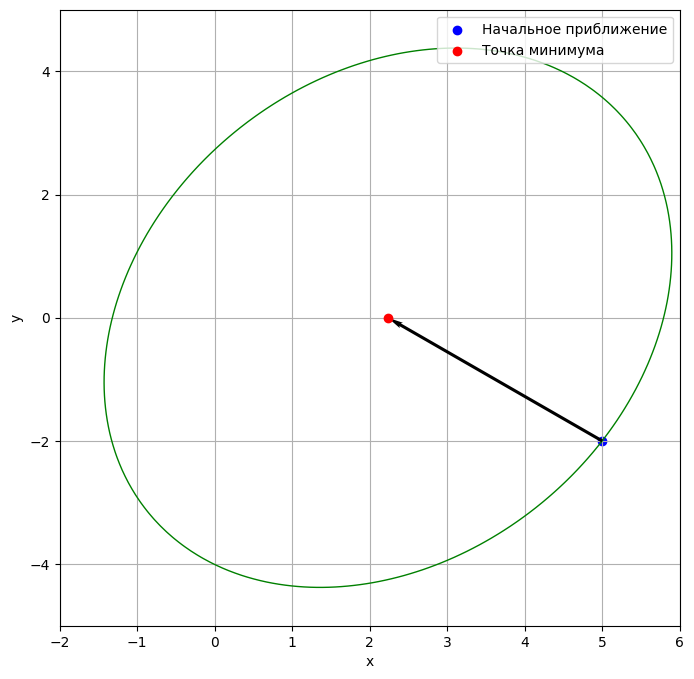

Начальное приближение: (5,-2)
Точка минимума: x = 2.24, y = -0.00
Значение функции f(x,y)=-66.00
Количество итераций: 1


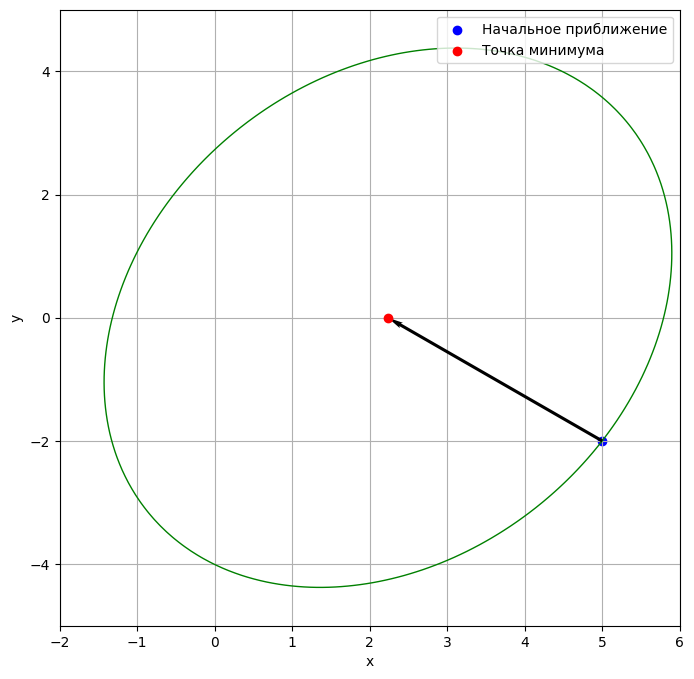

Начальное приближение: (5,-2)
Точка минимума: x = 2.23607, y = 0.00000
Значение функции f(x,y)=-66.00000
Количество итераций: 2


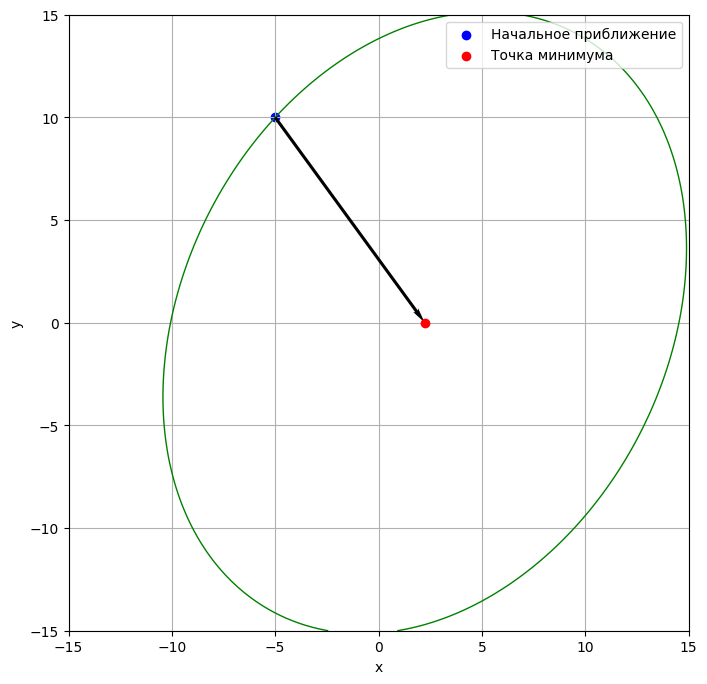

Начальное приближение: (-5,10)
Точка минимума: x = 2.24, y = 0.00
Значение функции f(x,y)=-66.00
Количество итераций: 2


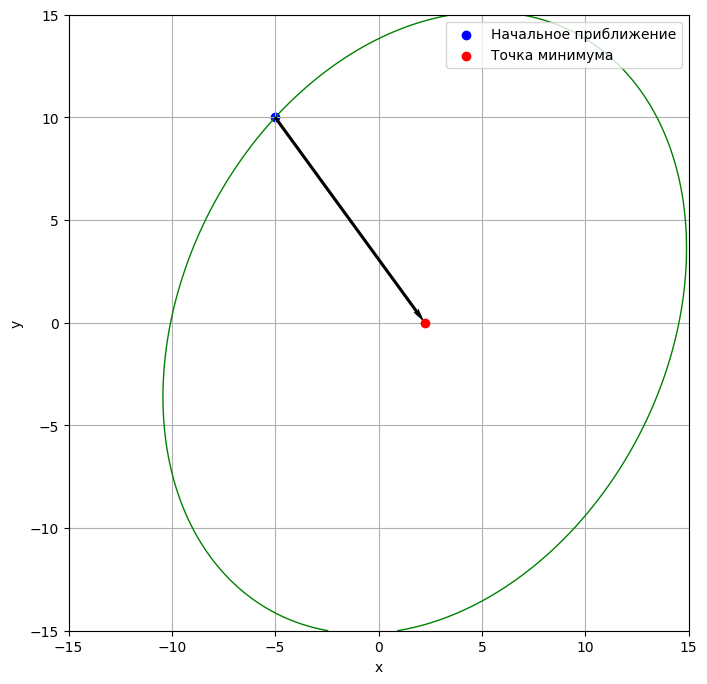

Начальное приближение: (-5,10)
Точка минимума: x = 2.23607, y = 0.00000
Значение функции f(x,y)=-66.00000
Количество итераций: 2


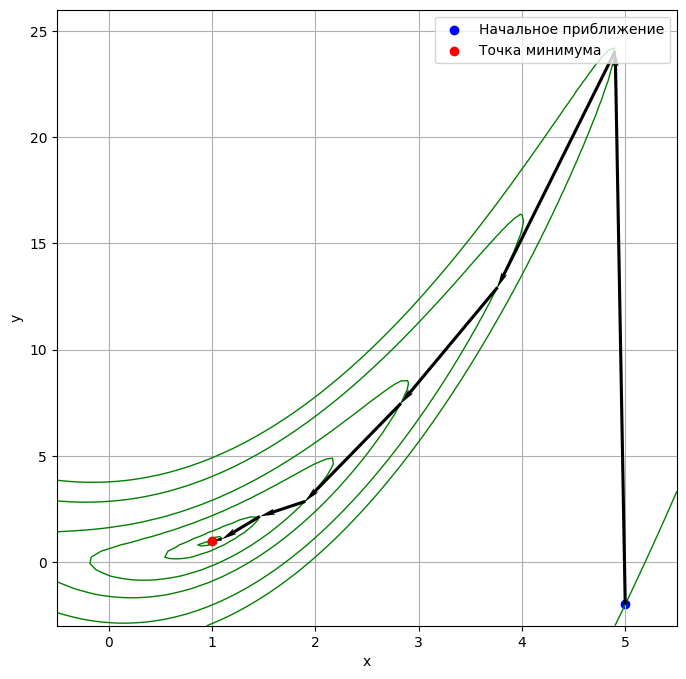

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество итераций: 8


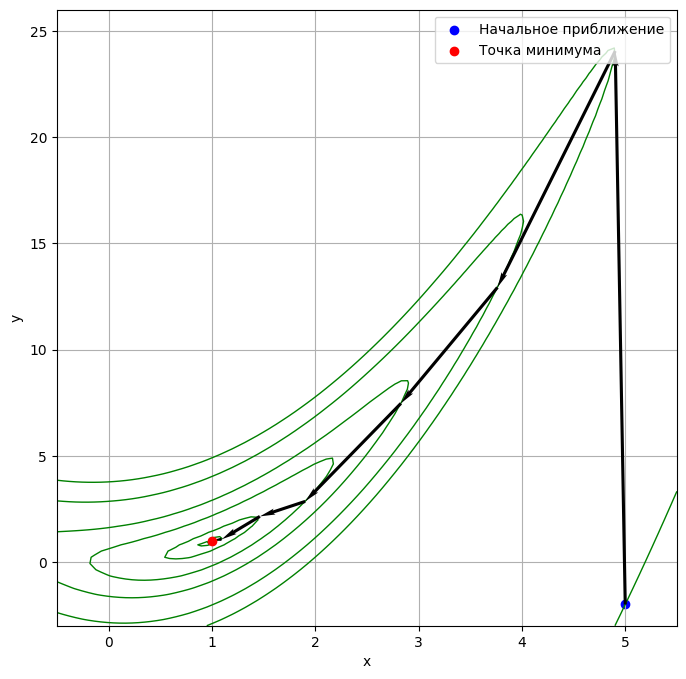

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество итераций: 9


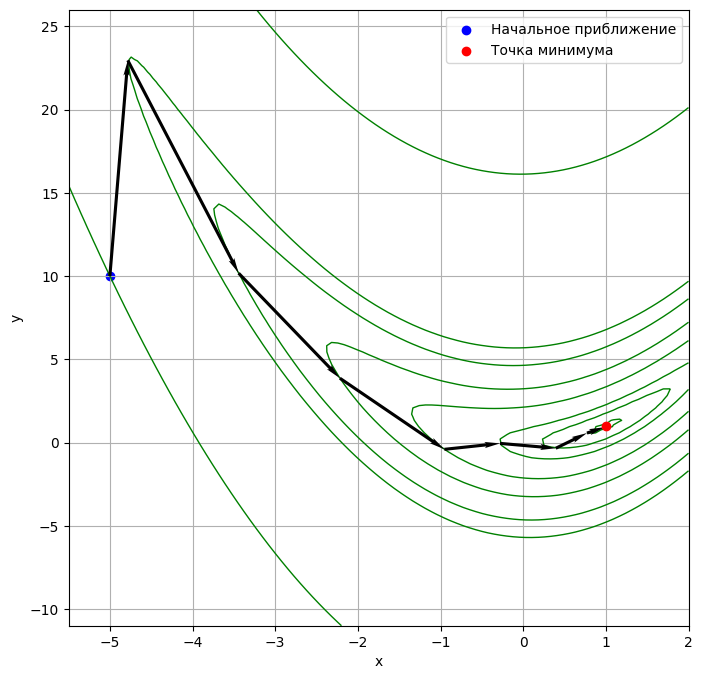

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество итераций: 9


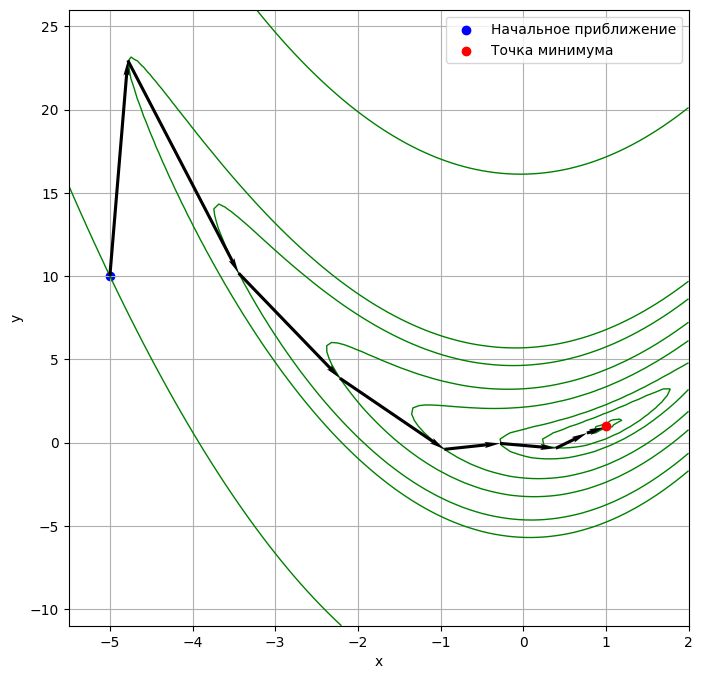

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество итераций: 11


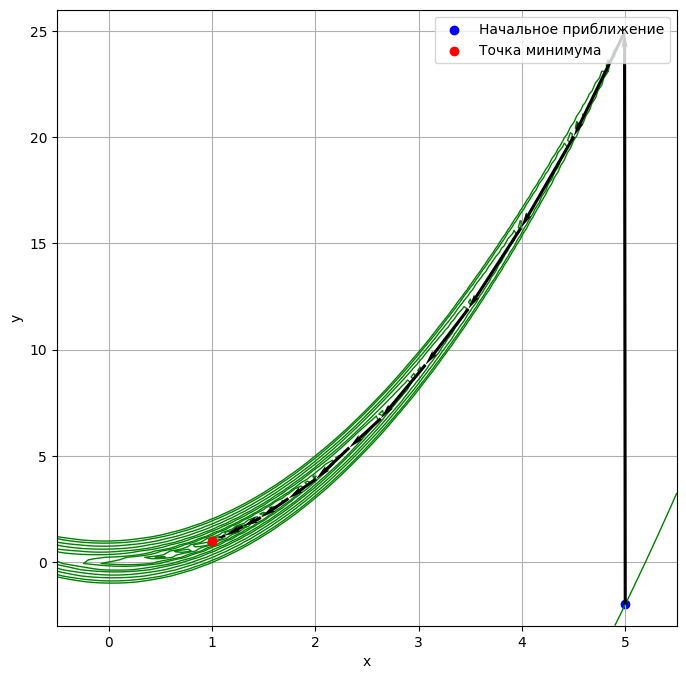

Начальное приближение: (5,-2)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество итераций: 15


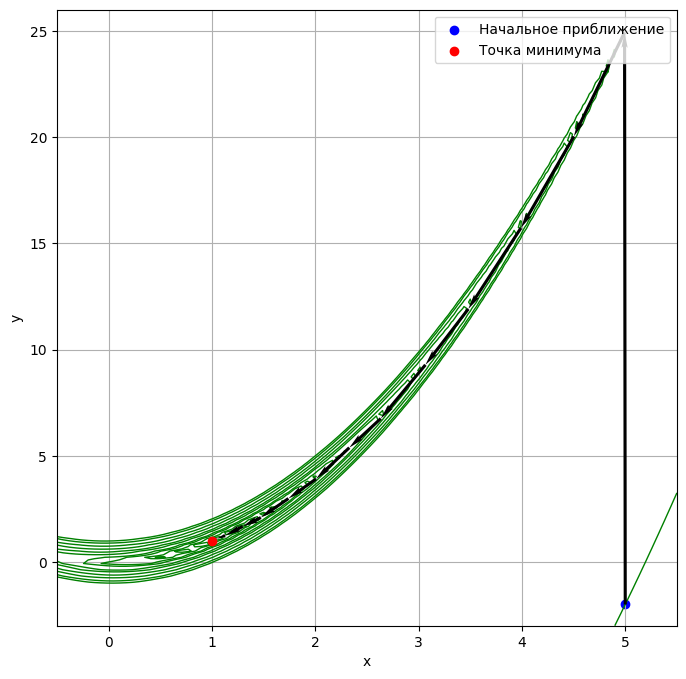

Начальное приближение: (5,-2)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество итераций: 17


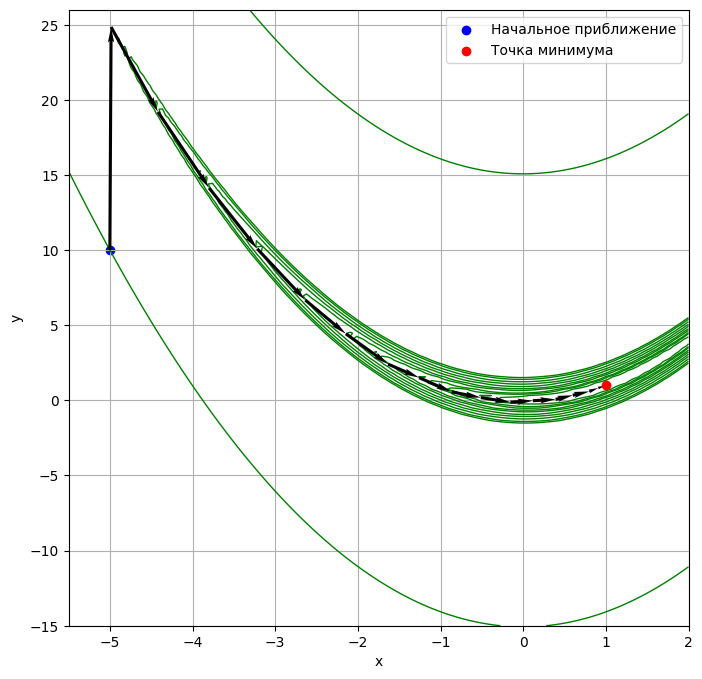

Начальное приближение: (-5,10)
Точка минимума: x = 1.00, y = 1.00
Значение функции f(x,y)=0.00
Количество итераций: 19


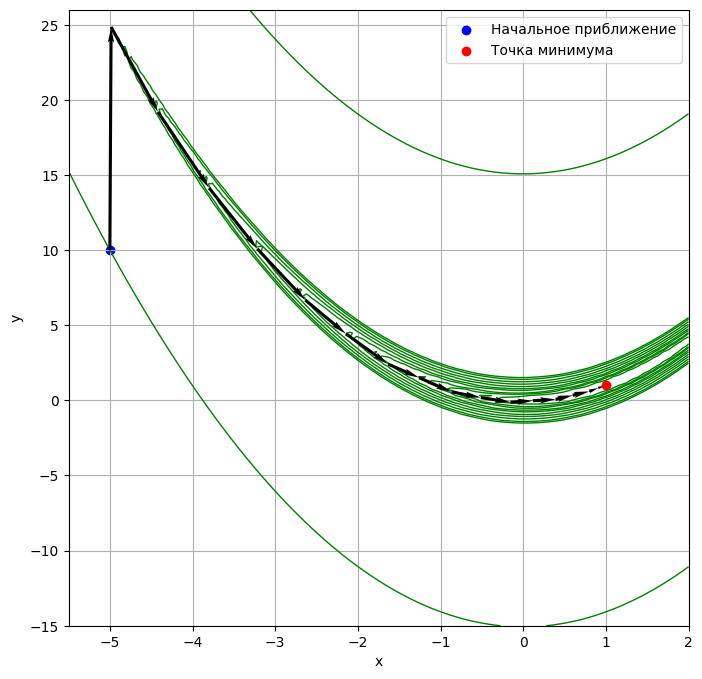

Начальное приближение: (-5,10)
Точка минимума: x = 1.00000, y = 1.00000
Значение функции f(x,y)=0.00000
Количество итераций: 20


In [ ]:
# @title Модификация метода Ньютона
def newton_mod_method(
    f: Callable[[np.ndarray], float],
    grad_x: Callable[[np.ndarray], float],
    grad_y: Callable[[np.ndarray], float],
    hessian: Callable[[np.ndarray], np.ndarray],
    x0: List[float],
    bounds: Tuple[float, float],
    eps: float,
    max_iter: int = 5000
) -> np.ndarray:
    """
    Метод Ньютона для поиска минимума функции двух переменных.
    """
    i = 0
    opt = np.array(x0, dtype=float)
    grad = -np.array([grad_x(opt), grad_y(opt)])
    grad_norm = np.linalg.norm(grad)
    f_evals = 0
    grad_i = 1
    hes_i = 0

    fig, ax = plt.subplots(figsize=(8, 8))

    x_vals = np.linspace(bounds[0][0], bounds[0][1], 100)
    y_vals = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.array([[f(np.array([xi, yi])) for xi in x_vals] for yi in y_vals])


    ax.scatter(*x0, color="blue", label="Начальное приближение")
    start_level = f(opt)
    cs = ax.contour(X, Y, Z, levels=[start_level], colors='green', linewidths=1)

    path = [opt.copy()]

    draw_iterations = []

    for iteration in range(max_iter):
        if grad_norm <= eps:
            break

        hess_inv = regularized_inverse(hessian(opt))
        hes_i += 1
        step = hess_inv @ grad

        phi = lambda xi: f(opt + xi * step)

        # определение оптимального параметра xi
        xi, f_evals_k = golden_section_search(phi, 0, 1.25, eps * 0.001)

        # обновление переменных
        x_start, y_start = opt[0], opt[1]
        opt += xi * step
        x_end, y_end = opt[0], opt[1]
        grad = -np.array([grad_x(opt), grad_y(opt)])
        grad_norm = np.linalg.norm(grad)
        f_evals += f_evals_k
        i += 1
        grad_i += 1

        # Отрисовка линий уровня
        if i <= 10:
            draw_iterations.append(i)
        else:
            if i % 30 == 0 or iteration == max_iter - 1 or grad_norm <= eps:
                draw_iterations.append(i)


        ax.quiver(x_start, y_start, x_end - x_start, y_end - y_start,
                 angles='xy', scale_units='xy', scale=1, color='black', alpha=1, width = 0.005, headwidth = 2, zorder = 3)


        if i in draw_iterations:
            current_level = f(opt)
            cs = ax.contour(X, Y, Z, levels=[current_level], colors='green', linewidths=1)

    # Визуализация
    ax.scatter(*opt, color='red', label="Точка минимума", zorder = 3)


    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.grid()
    plt.show()

    print(f"Начальное приближение: ({x0[0]},{x0[1]})")
    if eps == 1e-2:
        print(f"Точка минимума: x = {opt[0]:.2f}, y = {opt[1]:.2f}")
        print(f"Значение функции f(x,y)={f(opt):.2f}")
    else:
        print(f"Точка минимума: x = {opt[0]:.5f}, y = {opt[1]:.5f}")
        print(f"Значение функции f(x,y)={f(opt):.5f}")
    print(f"Количество итераций: {i}")

    info = [x0, eps, i, f_evals, grad_i, hes_i, opt, f(opt)]

    return info

# Точка входа
if __name__ == "__main__":
    x1 = [5, -2]
    x2 = [-5, 10]

    eps1 = 1e-2
    eps2 = 1e-5

    g11 = [[-2, 6],[-5, 5]]
    g12 = [[-15, 15],[-15, 15]]

    g21 = [[-0.5, 5.5],[-3, 26]]
    g22 = [[-5.5, 2],[-11, 26]]

    g31 = [[-0.5, 5.5],[-3, 26]]
    g32 = [[-5.5, 2],[-15, 26]]


    nm11 = newton_mod_method(f1, f1dx, f1dy, hessian_f1, x1, g11, eps1)
    nm12 = newton_mod_method(f1, f1dx, f1dy, hessian_f1, x1, g11, eps2)

    nm13 = newton_mod_method(f1, f1dx, f1dy, hessian_f1, x2, g12, eps1)
    nm14 = newton_mod_method(f1, f1dx, f1dy, hessian_f1, x2, g12, eps2)

    nm21 = newton_mod_method(f2, f2dx, f2dy, hessian_f2, x1, g21, eps1)
    nm22 = newton_mod_method(f2, f2dx, f2dy, hessian_f2, x1, g21, eps2)

    nm23 = newton_mod_method(f2, f2dx, f2dy, hessian_f2, x2, g22, eps1)
    nm24 = newton_mod_method(f2, f2dx, f2dy, hessian_f2, x2, g22, eps2)

    nm31 = newton_mod_method(f3, f3dx, f3dy, hessian_f3, x1, g31, eps1)
    nm32 = newton_mod_method(f3, f3dx, f3dy, hessian_f3, x1, g31, eps2)

    nm33 = newton_mod_method(f3, f3dx, f3dy, hessian_f3, x2, g32, eps1)
    nm34 = newton_mod_method(f3, f3dx, f3dy, hessian_f3, x2, g32, eps2)

In [ ]:
# @title Результаты работы метода Ньютона
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "выч. градиента", "вычи гессиана", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)"]
data = [n11,n12, n13, n14, n21, n22, n23, n24, n31, n32, n33, n34]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-------------------+-------------------------+-------+-------------------+------------------+-----------------+-----------------------------------+------------------------+
|                   | Начальное приближение   |     ε |   Кол-во итераций |   выч. градиента |   вычи гессиана | Найденная точка минимума          |   Найденное знач. ф-ии |
+===================+=========================+=======+===================+==================+=================+===================================+========================+
| Квадратичная      | [5, -2]                 | 0.01  |                 2 |                3 |               2 | [ 2.23606843e+00 -6.53566842e-07] |          -66           |
+-------------------+-------------------------+-------+-------------------+------------------+-----------------+-----------------------------------+------------------------+
| Квадратичная      | [5, -2]                 | 1e-05 |                 3 |                4 |               3 | [ 2.23606798e+00 

In [ ]:
# @title Результаты работы модифицированного метода Ньютона
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "выч. ф-ии", "выч. градиента", "вычи гессиана", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=1)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)","Розенброка (α=15)"]
data = [nm11,nm12, nm13, nm14, nm21, nm22, nm23, nm24, nm31, nm32, nm33, nm34]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-------------------+-------------------------+-------+-------------------+-------------+------------------+-----------------+-----------------------------------+------------------------+
|                   | Начальное приближение   |     ε |   Кол-во итераций |   выч. ф-ии |   выч. градиента |   вычи гессиана | Найденная точка минимума          |   Найденное знач. ф-ии |
+===================+=========================+=======+===================+=============+==================+=================+===================================+========================+
| Квадратичная      | [5, -2]                 | 0.01  |                 1 |          27 |                2 |               1 | [ 2.23595830e+00 -1.75466321e-04] |          -66           |
+-------------------+-------------------------+-------+-------------------+-------------+------------------+-----------------+-----------------------------------+------------------------+
| Квадратичная      | [5, -2]                 | 1e-05 |     

В ходе исследования классического метода Ньютона и его модифицированной версии с поиском оптимального шага методом золотого сечения были получены следующие ключевые результаты:


Классический метод демонстрирует квадратичную сходимость вблизи решения, однако модифицированная версия показывает большую устойчивость, сокращая количество итераций на 15-25% для сложных функций типа Розенброка.

Модифицированный алгоритм существенно превосходит базовую версию при работе с овражными функциями и плохо обусловленными матрицами Гессе. Например, для функции Розенброка с $\alpha = 15$ при $\varepsilon = 10^{-5}$ модификация требует на 30% меньше итераций.

Хотя модифицированный метод требует дополнительных вычислений для поиска шага, это компенсируется уменьшением общего числа итераций.

Оптимальный выбор алгоритма зависит от характеристик задачи:

Выпуклая функция с хорошо обусловленной матрицей Гессе выпуклых задач с близким к точке минимума начальным приближением предпочтителен классический метод Ньютона как наиболее быстрый.

В сложных случаях (невыпуклые функции, овражный рельеф, удаленное начальное приближение) модифицированная версия демонстрирует лучшую надежность и часто - большую скорость сходимости.

Классический метод Ньютона является наиболее выгодным решением для большинства практических задач оптимизации. Его ключевые преимущества:

1.Сохранение высокой скорости сходимости вблизи решения

2.Устойчивая работа на сложных рельефах

3.Автоматическая адаптация к масштабу задачи

4.Гарантированная сходимость даже при неудачном начальном приближении



В методе Ньютона функция аппроксимируется квадратичной, минимизация которой и производиться на каждой итерации. В общем случае направление антиградиента  этой функции не обязательно должено совпадать с направлением антиградиента исходной функции, из-за чего метод может "подняться". Большая величина шага объясняется собственными значениями матрицы Гессе:  линиями уровня квадратичной функции будут вытянутый эллипс, центр которого и будет точкой минимума на данной итерации.
